Mounted at /content/drive
📌 Device: cuda
🐝 Classes: ['Apicalis', 'Binghami', 'Biroi', 'Itama', 'Thoracica', 'Unknown', 'Vidua']
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 205MB/s]
Epoch 1/20: 100%|██████████| 70/70 [06:45<00:00,  5.79s/it]


Epoch 1: Val Acc=77.86%


Epoch 2/20: 100%|██████████| 70/70 [00:59<00:00,  1.17it/s]


Epoch 2: Val Acc=84.29%


...

Epoch 9: Val Acc=90.71%


Epoch 10/20: 100%|██████████| 70/70 [00:58<00:00,  1.19it/s]


Epoch 10: Val Acc=92.86%
⛔ Early stopping triggered

🚀 Training selesai — Best Val: 94.29%
📥 Model Loaded
📌 DLS index dibuat (1120 vectors)


Evaluating: 100%|██████████| 9/9 [00:59<00:00,  6.62s/it]



🎯 Test Accuracy: 92.14%

              precision    recall  f1-score   support

    Apicalis       0.95      0.90      0.92        20
    Binghami       0.93      0.70      0.80        20
       Biroi       0.87      1.00      0.93        20
       Itama       0.95      0.95      0.95        20
   Thoracica       1.00      0.95      0.97        20
     Unknown       0.83      0.95      0.88        20
       Vidua       0.95      1.00      0.98        20

    accuracy                           0.92       140
   macro avg       0.93      0.92      0.92       140
weighted avg       0.93      0.92      0.92       140



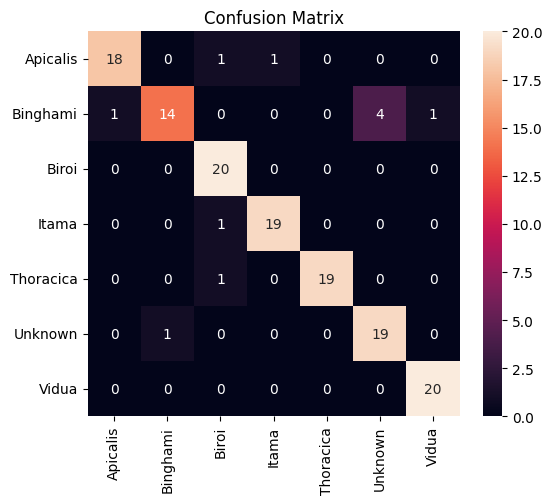

In [ ]:
# ============================================================
# 🐝 DENSENET121 + EMBEDDING + HYBRID OPENSET + DLS + Unknown
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ------------------------------------------------------------
# LIBRARIES
# ------------------------------------------------------------
import os, json, time
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import NearestNeighbors


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
DATA_ROOT = "/content/drive/MyDrive/Dataset Fix"
TRAIN_DIR = os.path.join(DATA_ROOT, "Latih")
VAL_DIR   = os.path.join(DATA_ROOT, "Validasi")
TEST_DIR  = os.path.join(DATA_ROOT, "Uji")

IMG_SIZE = 640
BATCH = 16
EPOCHS = 20
LR = 1e-4

CONF_THRESH = 0.80      # CNN confidence minimal dianggap valid
SIM_THRESH  = 0.60      # similarity minimal untuk tidak dianggap Unknown
USE_EARLY_STOP=True
PATIENCE=5

MODEL_PATH = "/content/drive/MyDrive/bee_densenet121_best640.pth"
EMBED_JSON_PATH = "/content/drive/MyDrive/bee_embeddings640.json"
DLS_INDEX_PATH = "/content/drive/MyDrive/bee_dls_index640.npz"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("📌 Device:", device)


# ------------------------------------------------------------
# DATA TRANSFORM & DATALOADER
# ------------------------------------------------------------
tf_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

tf_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=tf_train)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=tf_val)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=tf_val)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2)

class_names = train_ds.classes
print("🐝 Classes:", class_names)


# ------------------------------------------------------------
# DENSENET121 Model
# ------------------------------------------------------------

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_feat = model.classifier.in_features
model.classifier = nn.Linear(in_feat, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
def evaluate(loader):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for imgs,labels in loader:
            imgs,labels=imgs.to(device),labels.to(device)
            preds=model(imgs).argmax(1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
    return 100*correct/total

best_val=0
no_improve=0
for epoch in range(EPOCHS):
    model.train()
    for imgs,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs,labels=imgs.to(device),labels.to(device)
        optimizer.zero_grad()
        loss=criterion(model(imgs),labels)
        loss.backward()
        optimizer.step()
    val_acc=evaluate(val_loader)
    print(f"Epoch {epoch+1}: Val Acc={val_acc:.2f}%")
    if val_acc>best_val:
        best_val=val_acc
        torch.save(model.state_dict(),MODEL_PATH)
    else:
        no_improve += 1

    # EARLY STOP
    if USE_EARLY_STOP and no_improve >= PATIENCE:
        print("⛔ Early stopping triggered")
        break

print(f"\n🚀 Training selesai — Best Val: {best_val:.2f}%")


# ------------------------------------------------------------
# LOAD MODEL + EXTRACT EMBEDDING
# ------------------------------------------------------------
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print("📥 Model Loaded")

def extract_embedding(x):
    with torch.no_grad():
        feat=model.features(x)
        pooled=F.adaptive_avg_pool2d(feat,1).view(feat.size(0),-1)
    emb=pooled.cpu().numpy().squeeze().astype("float32")
    return emb/np.linalg.norm(emb)


emb_rows=[]
for cls in class_names:
    folder=os.path.join(TRAIN_DIR,cls)
    for file in os.listdir(folder):
        path=os.path.join(folder,file)
        img=Image.open(path).convert('RGB')
        x=tf_val(img).unsqueeze(0).to(device)
        emb=extract_embedding(x)
        emb_rows.append({"class":cls,"path":path,"embedding":emb.tolist()})

with open(EMBED_JSON_PATH,"w") as f:
    json.dump(emb_rows,f)

emb_matrix=np.vstack([np.array(r["embedding"]) for r in emb_rows])
nbrs=NearestNeighbors(metric="cosine",algorithm="brute").fit(emb_matrix)
np.savez(DLS_INDEX_PATH,emb_matrix=emb_matrix)

print(f"📌 DLS index dibuat ({emb_matrix.shape[0]} vectors)")


# ------------------------------------------------------------
# HYBRID PREDICT (CNN + DLS Unknown)
# ------------------------------------------------------------
def predict(img_tensor):
    with torch.no_grad():
        logits=model(img_tensor)
        probs=F.softmax(logits,dim=1).cpu().numpy().squeeze()

    top_idx=int(np.argmax(probs))
    pred_class=class_names[top_idx]
    top_conf=float(probs[top_idx])

    # Jika CNN yakin : return langsung
    if top_conf >= CONF_THRESH:
        return pred_class, top_conf, "CNN"

    # Jika ragu : cek embedding
    emb=extract_embedding(img_tensor)
    dist,idx=nbrs.kneighbors([emb],n_neighbors=1)
    nearest_class=emb_rows[idx[0][0]]["class"]
    similarity=float(1-dist[0][0])

    # Jika mirip class lain : assign class-nya
    if similarity >= SIM_THRESH:
        return nearest_class, similarity, "DLS-Fallback"

    # Jika tidak mirip : Unknown (Open set)
    return "Unknown", similarity, "Unknown"


# ------------------------------------------------------------
# EVALUASI
# ------------------------------------------------------------
y_true,y_pred=[],[]
for imgs,labels in tqdm(test_loader,desc="Evaluating"):
    for i in range(imgs.size(0)):
        img=imgs[i].unsqueeze(0).to(device)
        pred,sc,mode=predict(img)
        y_true.append(class_names[labels[i]])
        y_pred.append(pred)

acc=accuracy_score(y_true,y_pred)
print(f"\n🎯 Test Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_true,y_pred,target_names=class_names))


cm=confusion_matrix(y_true,y_pred,labels=class_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!python --version

Python 3.12.12
